In [ ]:
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import scipy as sp
from scipy import optimize
from scipy import fftpack
import skopt as opt
from skimage.color import rgb2gray
from skimage.restoration import denoise_tv_chambolle
from scipy.fftpack import dct, idct
import os
from rasterio.windows import from_bounds, Window


In [35]:
!pip install scikit-image


   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   -------------------------- ------------- 8.4/12.9 MB 52.1 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 35.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 44.7 MB/s eta 0:00:00


Lab 2:     PDF, stegenography & compressive sensing

Ex 1: PDF of Sentinel data

a) S2: I've choosen the same image of the same area: Tarnobrzeg, Subcarpatia (13.08.2025) 

Found bands: {'B04': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B04.jp2', 'B03': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B03.jp2', 'B02': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B02.jp2'}


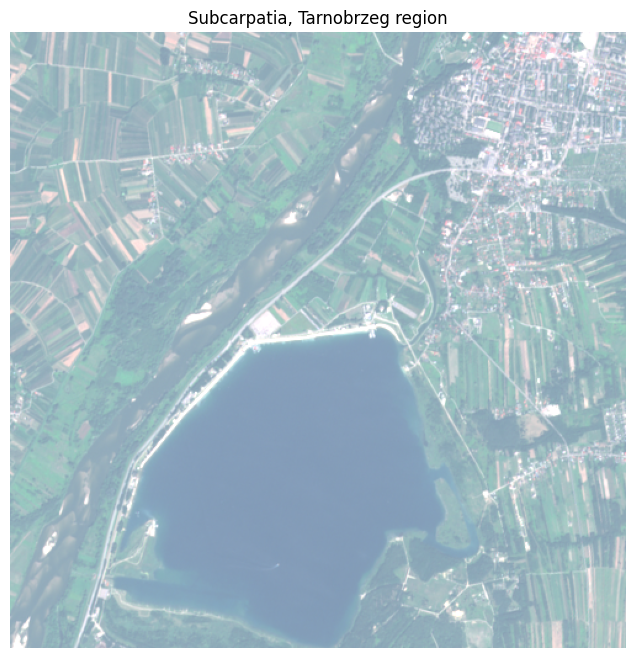

In [ ]:
#code from lab1
folder = r"C:\ml_amit\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\GRANULE\L1C_T34UEB_A052972_20250813T094043\IMG_DATA"
band_paths = {b: glob.glob(f"{folder}/T34UEB_20250813T094041_{b}.jp2")[0] for b in ["B04", "B03", "B02"]}
print("Found bands:", band_paths)

lon, lat = 21.6476, 50.5527   # top lake coordinates

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32634", always_xy=True)
x, y = transformer.transform(lon, lat)
dx = 2500
dy = 2500
xmin, ymin, xmax, ymax = x - dx, y - dy, x + dx, y + dy

## healper functions to load only the cropped area of interest instead of whole image
def read_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
    return data
##crop each band
b4_crop = read_crop(band_paths["B04"], (xmin, ymin, xmax, ymax))  # Red
b3_crop = read_crop(band_paths["B03"], (xmin, ymin, xmax, ymax))  # Green
b2_crop = read_crop(band_paths["B02"], (xmin, ymin, xmax, ymax))  # Blue

#stack normalize and exclude outliers
rgb_crop = np.dstack((b4_crop, b3_crop, b2_crop)).astype(np.float32)
rgb_crop /= np.percentile(rgb_crop, 99)
rgb_crop = np.clip(rgb_crop, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_crop)
plt.title("Subcarpatia, Tarnobrzeg region")
plt.axis("off")
plt.show()

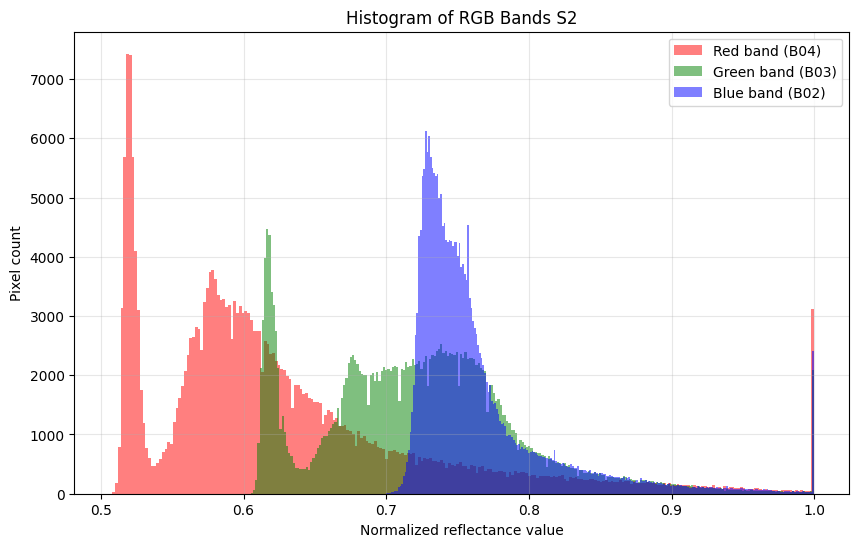

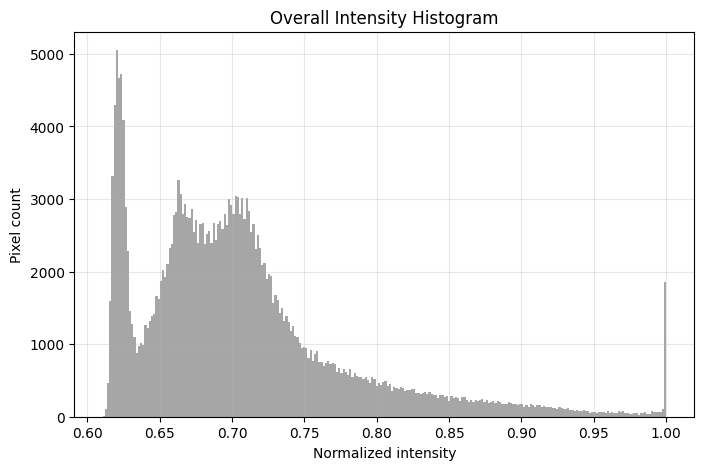

In [44]:
r = rgb_crop[:, :, 0].ravel()
g = rgb_crop[:, :, 1].ravel()
b = rgb_crop[:, :, 2].ravel()

r = r[np.isfinite(r)]
g = g[np.isfinite(g)]
b = b[np.isfinite(b)]

plt.figure(figsize=(10, 6))
plt.hist(r, bins=256, color='red', alpha=0.5, label='Red band (B04)')
plt.hist(g, bins=256, color='green', alpha=0.5, label='Green band (B03)')
plt.hist(b, bins=256, color='blue', alpha=0.5, label='Blue band (B02)')
plt.title("Histogram of RGB Bands S2")
plt.xlabel("Normalized reflectance value")
plt.ylabel("Pixel count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

intensity = np.mean(rgb_crop, axis=2).ravel()
intensity = intensity[np.isfinite(intensity)]



plt.figure(figsize=(8, 5))
plt.hist(intensity, bins=256, color='gray', alpha=0.7)
plt.title("Overall Intensity Histogram")
plt.xlabel("Normalized intensity")
plt.ylabel("Pixel count")
plt.grid(alpha=0.3)
plt.show()


The histogram shows distinct distributions for the Red (B04), Green (B03), and Blue (B02) bands.

The Red band peaks at lower reflectance (≈0.55–0.6) due to strong chlorophyll absorption.

The Green and Blue bands peak higher (≈0.65–0.75), typical of vegetation and bright surfaces.

All bands are right-skewed, with a few bright pixels (likely soil, urban areas, or clouds).

Overall, the shape reflects a vegetated landscape with mixed land cover — low red reflectance, moderate green, and higher blue responses.

In [ ]:

print(rasterio.open(vv_path).crs)

None


b) S1: same area but from S1 and day later (15.08.2025)

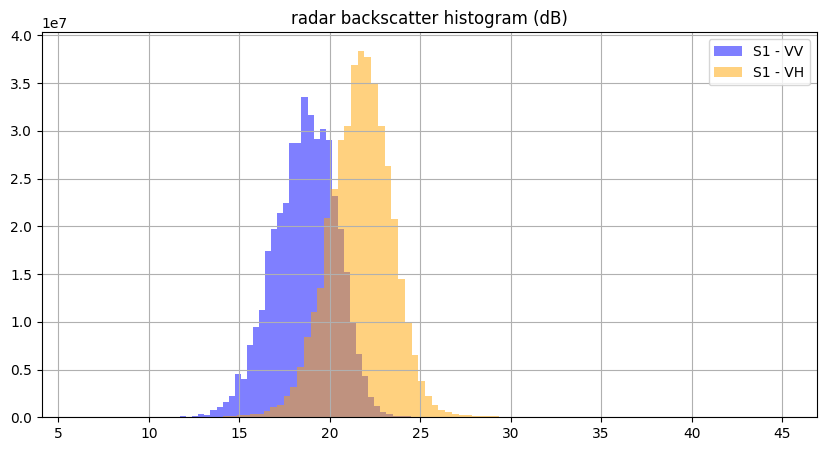

In [43]:
lon, lat  = 21.6476, 50.5527   # top lake coordinates
dx, dy    = 2500, 2500

s1_file_1 = r"C:\ml_amit\S1C_IW_GRDH_1SDV_20250813T044349_20250813T044414_003649_0074CC_749E.SAFE\measurement\s1c-iw-grd-vh-20250813t044349-20250813t044414-003649-0074cc-002.tiff"  # np. VH z 20 października
s1_file_2 = r"C:\ml_amit\S1C_IW_GRDH_1SDV_20250813T044349_20250813T044414_003649_0074CC_749E.SAFE\measurement\s1c-iw-grd-vv-20250813t044349-20250813t044414-003649-0074cc-001.tiff"  # np. VV z 20 października

def read_window(path, lon, lat, dx, dy):
    with rasterio.open(path) as src:
        
        crs_raster = src.crs or "EPSG:4326"
        transformer = Transformer.from_crs("EPSG:4326", crs_raster, always_xy=True)

       
        x, y = transformer.transform(lon, lat)

        transform = src.transform
        W, H = src.width, src.height

        
        if abs(transform.a) < 0.001:  
            dx_deg = dx / 111320
            dy_deg = dy / 111320
        else:
            dx_deg = dx
            dy_deg = dy

        xmin, ymin, xmax, ymax = x - dx_deg, y - dy_deg, x + dx_deg, y + dy_deg

        
        try:
            win = from_bounds(xmin, ymin, xmax, ymax, transform=transform)
        except Exception:
           
            rleft, rbottom, rright, rtop = src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top
            xmin = max(xmin, rleft)
            xmax = min(xmax, rright)
            ymin = max(ymin, rbottom)
            ymax = min(ymax, rtop)
            if xmin >= xmax or ymin >= ymax:
               
                win = Window(0, 0, W, H)
            else:
                win = from_bounds(xmin, ymin, xmax, ymax, transform=transform)

       
        col_off = int(np.floor(win.col_off))
        row_off = int(np.floor(win.row_off))
        width = int(np.ceil(win.width))
        height = int(np.ceil(win.height))

        col_off = max(0, min(col_off, max(0, W - 1)))
        row_off = max(0, min(row_off, max(0, H - 1)))
        width = max(0, min(width, W - col_off))
        height = max(0, min(height, H - row_off))

        if width == 0 or height == 0:
            
            return np.empty((0, 0), dtype=np.float32), crs_raster

        win = Window(col_off, row_off, width, height)

        
        arr = src.read(1, window=win, boundless=True, fill_value=np.nan).astype(np.float32)
        arr[arr <= 0] = np.nan
        return arr, crs_raster


s1_img1, crs1 = read_window(s1_file_1, lon, lat, dx, dy)
s1_img2, crs2 = read_window(s1_file_2, lon, lat, dx, dy)


if s1_img1.size == 0 and s1_img2.size > 0:
    s1_img1 = np.full_like(s1_img2, np.nan)
elif s1_img2.size == 0 and s1_img1.size > 0:
    s1_img2 = np.full_like(s1_img1, np.nan)
elif s1_img1.size == 0 and s1_img2.size == 0:
    raise RuntimeError("Both loaded windows are empty. Check coordinates and input files.")

s1_db1 = 10 * np.log10(s1_img1)
s1_db2 = 10 * np.log10(s1_img2)

plt.figure(figsize=(10, 5))
plt.hist(np.ravel(s1_db1[~np.isnan(s1_db1)]), bins=100, color="blue", alpha=0.5, label="S1 - VV")
plt.hist(np.ravel(s1_db2[~np.isnan(s1_db2)]), bins=100, color="orange", alpha=0.5, label="S1 - VH")
plt.title("radar backscatter histogram (dB)")
plt.legend()
plt.grid(True)
plt.show()

The histogram displays the distribution of radar backscatter values for Sentinel-1 VV and VH polarizations.

VV backscatter peaks around 17–20 dB, while VH peaks slightly higher (20–23 dB).

The VH band has a broader spread, indicating more variation in cross-polarized returns caused by vegetation or rough surfaces.

VV values are generally stronger for urban or smooth surfaces, where double-bounce reflections dominate.

Low backscatter (left side, <15 dB) likely represents water bodies or smooth terrain, which reflect radar energy away from the sensor.

Overall, the histogram shape is typical for mixed land cover — low backscatter from water, moderate from vegetation, and higher values from built-up areas.

Ex. 2: Stegenography (for s2)

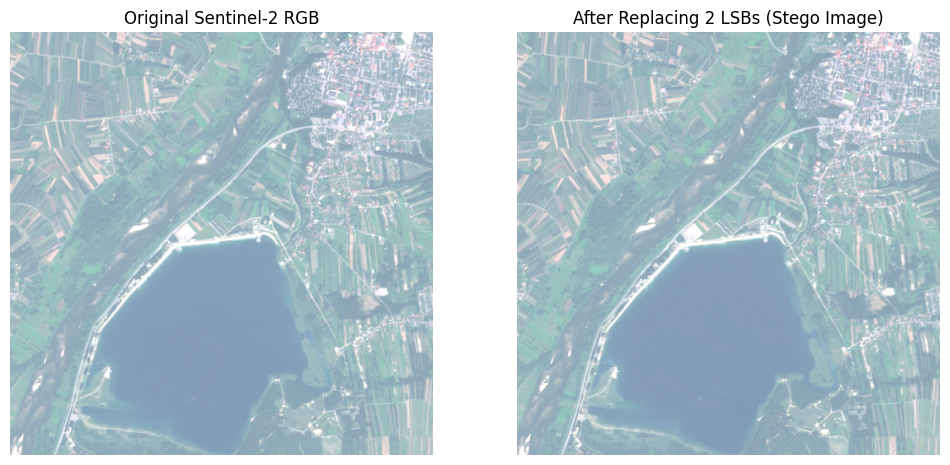

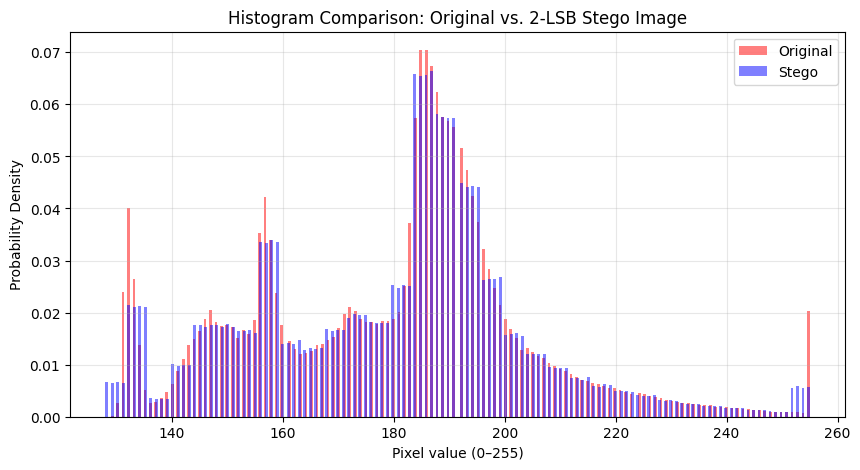

In [47]:
img_uint8 = (rgb_crop * 255).astype(np.uint8)
img_stego = img_uint8.copy()
random_bits = np.random.randint(0, 4, size=img_uint8.shape, dtype=np.uint8) 

img_stego = (img_uint8 & 0b11111100) | random_bits
img_stego_norm = img_stego.astype(np.float32) / 255.0


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rgb_crop)
plt.title("Original Sentinel-2 RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_stego_norm)
plt.title("After Replacing 2 LSBs (Stego Image)")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 5))

orig_vals = img_uint8.ravel()
stego_vals = img_stego.ravel()

plt.hist(orig_vals, bins=256, color="red", alpha=0.5, label="Original", density=True)
plt.hist(stego_vals, bins=256, color="blue", alpha=0.5, label="Stego",  density=True)

plt.title("Histogram Comparison: Original vs. 2-LSB Stego Image")
plt.xlabel("Pixel value (0–255)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The two Sentinel-2 images (org and mod) appear visually identical, showing that altering the least significant bits does not affect image quality perceptibly (at least for my case i might not see it, its late rn).
However, the histogram comparison reveals small differences — the stego image (blue) has a slightly smoother distribution, as random bit replacement disrupts the fine pixel-value structure of the original (red).

This indicates that while steganographic changes are invisible to the eye, they can be detected statistically by analyzing pixel intensity distributions.

Ex. 3: compressive sensing code

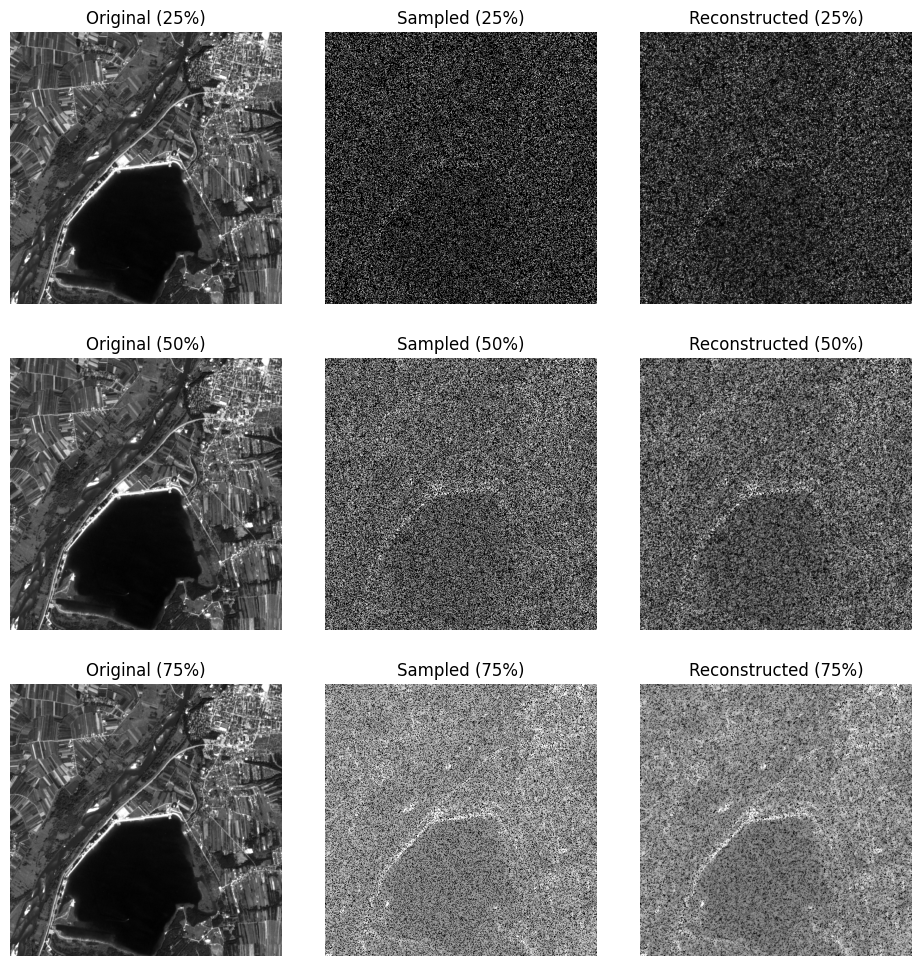

In [ ]:


img_gray = rgb2gray(rgb_crop)
m, n = img_gray.shape


def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')


ratios = [0.25, 0.5, 0.75]   #samplning ratios
results = []

np.random.seed(33)

for r in ratios:
    num_samples = int(r * m * n)
    mask = np.zeros((m, n), dtype=bool)
    mask.ravel()[np.random.choice(m * n, num_samples, replace=False)] = True

    sampled_img = np.zeros_like(img_gray)
    sampled_img[mask] = img_gray[mask]

    # DCT + inverse DCT reconstruction with total variation denoising
    img_dct = dct2(sampled_img)
    reconstructed = denoise_tv_chambolle(idct2(img_dct), weight=0.1)

    results.append((r, sampled_img, reconstructed))


fig, axes = plt.subplots(3, 3, figsize=(12, 12))
plt.subplots_adjust(wspace=0.05, hspace=0.2)

for i, (r, sampled, recon) in enumerate(results):
    # Original
    axes[i, 0].imshow(img_gray, cmap="gray")
    axes[i, 0].set_title(f"Original ({int(r*100)}%)")
    axes[i, 0].axis("off")

    # Sampled
    axes[i, 1].imshow(sampled, cmap="gray")
    axes[i, 1].set_title(f"Sampled ({int(r*100)}%)")
    axes[i, 1].axis("off")

    # Reconstructed
    axes[i, 2].imshow(recon, cmap="gray")
    axes[i, 2].set_title(f"Reconstructed ({int(r*100)}%)")
    axes[i, 2].axis("off")


plt.show()


The figure shows compressive sensing reconstruction of the Sentinel-2 image at different sampling levels:

25% sampling: The sampled image is highly sparse, and the reconstructed version is blurry but still captures the main scene structure.

50% sampling: The reconstruction significantly improves; most major features (lake, roads, fields) become distinguishable.

75% sampling: The reconstructed image closely matches the original, with less quality loss.


Compressive sensing is valuable in EO for:

-Onboard data compression: reducing the volume of data satellites need to transmit to Earth.

-Hyperspectral imaging: reconstructing full spectral cubes from limited measurements.

-SAR and radar imaging: enabling sparse signal acquisition and faster scanning.

-Cloud-gap filling and data recovery: reconstructing missing or corrupted regions in optical or radar imagery.

In summary, CS allows high-quality reconstruction from fewer samples, making it a powerful tool for efficient, low-bandwidth satellite imaging and data restoration in Earth Observation.